# Imports

In [63]:
import pandas as pd
import numpy as np
import pyarrow as pa
import os
from joblib import Parallel, delayed
from tqdm import tqdm
import plotly.express as px
import matplotlib.pyplot as plt
import ast
import warnings

# Dev Space

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 300)

In [3]:
file_path = 'E:/ML/datasets/mahjong/data/2019/block_5000.parquet'

In [4]:
states = pd.read_parquet(file_path)

In [5]:
states.columns = states.columns.map(
    str
)

In [6]:
dora_columns = []
for i in range(34,68):
    dora_columns = dora_columns + [str(i)]

In [7]:
hand_columns = []
for i in range(68,102):
    hand_columns = hand_columns + [str(i)]

In [8]:
states['round_id'] = states['511'].astype(str) + states['32'].astype(str)

In [9]:
columns_of_interest = ['round_id'] + ['0','1','2','5','6','7','8','9','10','11','12','13'] + dora_columns + hand_columns + ['510']

In [10]:
states = states[columns_of_interest] 

In [11]:
column_translations = {
    '0':'Round Wind',
    '1':'Dealer',
    '2':'POV Player',
    '5':'Wall Tiles',
    '6':'P0 Score',
    '7':'P1 Score',
    '8':'P2 Score',
    '9':'P3 Score',
    '10':'P0 Riichi',
    '11':'P1 Riichi',
    '12':'P2 Riichi',
    '13':'P3 Riichi',
    '510':'Discard'
}

In [12]:
states = states.rename(columns=column_translations)

In [13]:
states[states.columns[1:]] = states[states.columns[1:]].astype(int)

In [14]:
states_dora_sum = states.loc[:, dora_columns].sum(axis=1)

In [15]:
states = states.loc[states_dora_sum == 1].copy()

In [16]:
grouped_states_size = states.groupby('round_id').size()

In [17]:
over_10 = grouped_states_size.loc[grouped_states_size >= 10]

In [18]:
states = states.loc[states['round_id'].isin(over_10.index)]

In [19]:
single_round = states.loc[states['round_id'] == '009379d90']

## Round 2 Vec

In [20]:
def get_perspective_position(metadata_vector):
    n = metadata_vector['POV Player']
    arr = np.asarray(metadata_vector['P0 Score':'P3 Score'])
    if np.all(arr == arr[0]):
        return 'tie'
    position = int(np.sum(arr < arr[n]))

    position_dict = {0:'1st',
                     1:'2nd',
                     2:'3rd',
                     3:'4th'}
    return position_dict[position]

In [21]:
def drop_nth(s, n):
    mask = np.ones(len(s), dtype=bool)
    mask[n] = False
    return s.iloc[mask]

In [22]:
def id_to_tile(id):
    return id %34

In [23]:
def normalize_seats(seats_vector):
    persp_seat = seats_vector.iloc[-1]
    persp_dict = {persp_seat: "P",
                  (persp_seat+1)%4: "R",
                  (persp_seat-1)%4: "L",
                  (persp_seat+2)%4: "A"}
    return seats_vector.replace(persp_dict)

In [24]:
mahjong_tiles = [
    # Manzu (Characters)
    "1m", "2m", "3m", "4m", "5m", "6m", "7m", "8m", "9m",
    
    # Souzu (Bamboos)
    "1s", "2s", "3s", "4s", "5s", "6s", "7s", "8s", "9s",
    
    # Pinzu (Circles)
    "1p", "2p", "3p", "4p", "5p", "6p", "7p", "8p", "9p",
    
    # Winds
    "East", "South", "West", "North",
    
    # Dragons (Colors)
    "White", "Green", "Red"
]

In [25]:
def round_2_vec(rnd):
    # Metadata section
    metadata_vector = rnd.iloc[-1].drop(hand_columns)
    
    lookup = np.array(['E','S','W','N'])
    round_wind = lookup[metadata_vector['Round Wind']]

    seat_wind = lookup[(metadata_vector['POV Player'] - metadata_vector['Dealer']) % 4]

    if (metadata_vector['POV Player'] == metadata_vector['Dealer']):
        is_dealer = 'dealer'
    else:
        is_dealer = 'nondealer'

    if metadata_vector['Wall Tiles'] < 20:
        wall = 'WU20'
    else:
        wall = 'WOoA20'

    relative_score = get_perspective_position(metadata_vector)

    if metadata_vector['P0 Riichi':'P3 Riichi'].iloc[metadata_vector['POV Player']]:
        did_riichi = 'did_riichi'
    else:
        did_riichi = 'no_riichi'
        
    other_riichis = f'{sum(drop_nth(metadata_vector['P0 Riichi':'P3 Riichi'],metadata_vector['POV Player']))}_OR'

    dora_series = metadata_vector[dora_columns]

    dora = id_to_tile(int(dora_series.loc[dora_series==1].index[0]))

    dora = f'D{mahjong_tiles[dora]}'

    # Discard Section
    discards = rnd['Discard']
    discard_vector = pd.Series(np.take(mahjong_tiles, discards.values), index=discards.index)
    discard_vector = normalize_seats(rnd['POV Player']) + discard_vector
    
    return np.concatenate(([round_wind], [seat_wind], [wall], [relative_score], [did_riichi], [other_riichis], [dora], discard_vector))

In [26]:
round_2_vec(single_round)

array(['E', 'W', 'WOoA20', 'tie', 'no_riichi', '0_OR', 'D5m', 'ASouth',
       'LSouth', 'P8p', 'RSouth', 'AWhite', 'L9s', 'PWhite', 'R1p', 'A9s',
       'LRed', 'PEast', 'REast', 'A7p', 'LWest', 'P1m', 'R8p', 'A2p',
       'L9m', 'P2m', 'A4p', 'L6s', 'PWest', 'R8s', 'A3p', 'L1m', 'P5p',
       'R7p', 'A5p', 'L1m', 'P7s', 'A6s', 'L3s', 'A4s', 'LWhite', 'P7p'],
      dtype=object)

## Identify Chiitoi States

In [27]:
is_chiitoi = (states[hand_columns].astype(int) == 2).sum(axis=1) == 6

In [28]:
is_chiitoi.value_counts()

False    2331268
True        7304
Name: count, dtype: int64

In [29]:
states['is_chiitoi'] = is_chiitoi

In [30]:
states

,round_id,Round Wind,Dealer,POV Player,Wall Tiles,P0 Score,P1 Score,P2 Score,P3 Score,P0 Riichi,P1 Riichi,P2 Riichi,P3 Riichi,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,Discard,is_chiitoi
0,009379d90,0,0,0,69,25,25,25,25,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,2,0,0,0,1,0,1,0,1,0,1,0,0,1,0,0,0,1,0,0,1,0,3,28,False
1,009379d90,0,0,1,68,25,25,25,25,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,1,0,0,1,0,0,0,1,1,1,0,0,0,0,1,0,1,0,3,1,28,False
2,009379d90,0,0,2,67,25,25,25,25,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,2,2,0,0,0,0,0,1,1,0,0,0,1,0,1,0,0,1,0,1,0,0,0,1,0,0,25,False
3,009379d90,0,0,3,66,25,25,25,25,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,2,0,0,0,0,0,1,2,0,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,1,1,0,0,0,0,0,28,False
4,009379d90,0,0,0,65,25,25,25,25,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,2,0,0,1,1,0,1,0,1,0,1,0,0,1,0,0,0,0,0,0,1,0,3,31,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2412913,883fb84512,1,3,3,24,30,24,15,32,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,1,1,1,1,0,1,1,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,33,False
2412914,883fb84512,1,3,0,23,24,15,32,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,2,2,0,0,0,1,0,1,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,22,False
2412915,883fb84512,1,3,1,22,15,32,30,24,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,1,0,0,0,0,1,0,0,1,2,0,0,0,1,2,2,0,0,0,0,0,0,0,0,0,0,0,1,False
2412916,883fb84512,1,3,2,22,32,30,24,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,2,0,0,0,0,23,False


In [31]:
mask = states.groupby('round_id')['is_chiitoi'] \
         .transform('any')

result = states[mask]

In [32]:
# 1. find the index of the first True for each group
first_real = (
    result[result['is_chiitoi']]
    .groupby('round_id', sort=False)
    .apply(lambda g: g.index[0])
    .rename('first_idx')
)

# 2. map that back onto every row in df
result = result.reset_index()  # make the original index a column so we can compare to first_idx
result['first_idx'] = result['round_id'].map(first_real)

# 3. keep only rows whose original index is <= that group’s first_idx
df_truncated = (
    result[result['index'] <= result['first_idx']]
    .drop(['first_idx', 'index', 'is_chiitoi'], axis=1)
    .reset_index(drop=True)
)

C:\Users\Efith\AppData\Local\Temp\ipykernel_26064\350692415.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.index[0])


In [33]:
trunc_sizes = df_truncated.groupby('round_id').size()

In [34]:
df_truncated = df_truncated.loc[df_truncated['round_id'].isin(trunc_sizes[trunc_sizes >= 10].index)]

In [35]:
chiitois = df_truncated.groupby('round_id').apply(round_2_vec, include_groups=False)

In [36]:
chiitois

round_id
0009fd001     [E, E, WOoA20, 4th, no_riichi, 0_OR, D6m, PSou...
001ada941     [E, S, WU20, 2nd, did_riichi, 0_OR, DRed, LNor...
0028d7e52     [E, S, WOoA20, 1st, no_riichi, 0_OR, D9m, L1p,...
0029172e7     [S, S, WOoA20, 1st, did_riichi, 0_OR, DWhite, ...
0029172e9     [S, E, WOoA20, 1st, no_riichi, 0_OR, D5p, PSou...
                                    ...                        
fed73a282     [E, W, WOoA20, 4th, no_riichi, 0_OR, D4p, AWes...
fefb6acb0     [E, W, WOoA20, tie, no_riichi, 0_OR, D2p, ANor...
ff2e373310    [S, N, WOoA20, 4th, no_riichi, 0_OR, D6m, R9s,...
ff3b5cdf3     [E, W, WOoA20, 4th, no_riichi, 1_OR, D9s, A9p,...
ffa43bcd11    [S, E, WOoA20, 4th, no_riichi, 1_OR, D3s, PWes...
Length: 3167, dtype: object

## Get Chiitoi Round Length Distribution

In [37]:
chiitoi_lengths = df_truncated.groupby('round_id').size().reset_index(drop=True)

In [38]:
chiitoi_lengths.sort_values()

303     10
1698    10
2368    10
495     10
358     10
        ..
209     72
2579    73
250     74
511     74
1571    75
Length: 3167, dtype: int64

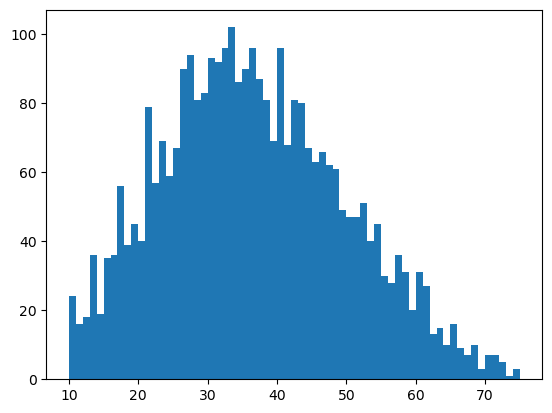

In [39]:
plt.hist(chiitoi_lengths, bins=(chiitoi_lengths.max() - chiitoi_lengths.min()))
plt.show()

In [40]:
result_non = states[~mask]

In [41]:
non_chiitoi_lengths = result_non.groupby('round_id').size().reset_index(drop=True)

In [42]:
bins_needed = non_chiitoi_lengths.max() - non_chiitoi_lengths.min()

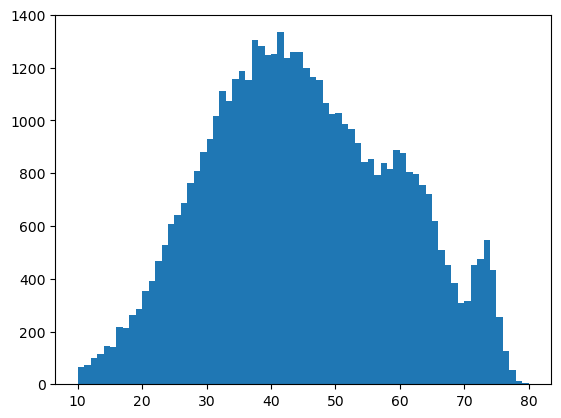

In [43]:
plt.hist(non_chiitoi_lengths, bins=bins_needed)
plt.show()

In [48]:
group_sizes = result_non.groupby('round_id').size()

In [49]:
import numpy as np
import pandas as pd

def downscale_to_match(chiitoi_lengths: pd.Series,
                       group_sizes:      pd.Series
                       ) -> pd.Series:
    """
    Return a Series the same length as `group_sizes` whose values

      • have (almost) the same *relative* frequency distribution
        as `chiitoi_lengths` (scaled up to 48 971 rows);
      • never exceed their own original value; and
      • keep every single row of `group_sizes`.
    """
    chi_vals = chiitoi_lengths.to_numpy()
    gs_vals  = group_sizes.to_numpy()
    gs_idx   = group_sizes.index.to_numpy()

    vmax = max(gs_vals.max(), chi_vals.max())

    # ------------------------------------------------------------------
    # 1)  Desired histogram  (scale χ​iitoi to 48 971 rows)
    # ------------------------------------------------------------------
    chi_counts   = np.bincount(chi_vals, minlength=vmax + 1).astype(float)
    proportions  = chi_counts / chi_counts.sum()

    desired      = proportions * len(gs_vals)          # float
    target       = np.floor(desired).astype(int)       # first allocate floors
    # distribute the rounding leftovers to the largest residuals
    leftover     = len(gs_vals) - target.sum()
    if leftover:                                       # ‹≈ vmax + 1› ≤ 100
        extras = np.argsort(desired - target)[-leftover:]
        target[extras] += 1

    # ------------------------------------------------------------------
    # 2)  Make the target *feasible* (cannot ask for more rows with value v
    #     than we actually have with ≥ v).  Walk top-down and push any
    #     excess to the next-lower bucket.
    # ------------------------------------------------------------------
    avail = np.bincount(gs_vals, minlength=vmax + 1)
    for v in range(vmax, 0, -1):
        excess = max(0, target[v] - avail[v])
        if excess:
            target[v]  -= excess
            target[v-1] += excess                       # push down one step

    # After the sweep, ∑target == len(gs_vals)          and
    #                target[v] ≤ rows with original ≥ v

    # ------------------------------------------------------------------
    # 3)  Concrete assignment in one pass over a *sorted* view
    # ------------------------------------------------------------------
    order         = np.argsort(-gs_vals)                # descending
    gs_desc       = gs_vals[order]
    idx_desc      = gs_idx[order]

    new_vals_desc = np.empty_like(gs_desc)
    ptr = 0
    for v in range(vmax, -1, -1):
        k = target[v]
        if k == 0:
            continue
        stop = ptr + k                                  # rows [ptr:stop)
        # by construction gs_desc[ptr:stop] ≥ v
        new_vals_desc[ptr:stop] = v
        ptr = stop                                      # move the front marker

    # ------------------------------------------------------------------
    # 4)  Re-order back to the original index order
    # ------------------------------------------------------------------
    new_vals = new_vals_desc[np.argsort(order)]
    return pd.Series(new_vals, index=group_sizes.index, name='new_group_size')


# ----------------------------------------------------------------------
# Example use
new_group_sizes = downscale_to_match(chiitoi_lengths, group_sizes)

# quick sanity checks --------------------------------------------------
#   1) nobody was raised:
assert (new_group_sizes <= group_sizes).all()
#   2) length is unchanged:
assert len(new_group_sizes) == len(group_sizes)
#   3) distribution close (± 1 row because of rounding):
print(
    (new_group_sizes.value_counts()
     .sort_index()
     / len(new_group_sizes)).head(10)      # or compare χ², KL-divergence, …
)


new_group_size
0     0.223581
10    0.001348
11    0.001491
12    0.002042
13    0.002307
14    0.002981
15    0.002859
16    0.004431
17    0.004390
18    0.005330
Name: count, dtype: float64


In [50]:
new_group_sizes = new_group_sizes.loc[new_group_sizes!=0]

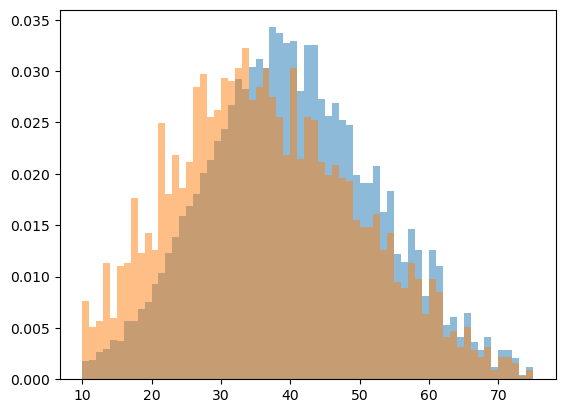

In [51]:
bins_needed = new_group_sizes.max() - new_group_sizes.min()
plt.hist(new_group_sizes, alpha=0.5, density=True, bins=bins_needed)
plt.hist(chiitoi_lengths, alpha=0.5, density=True, bins=(chiitoi_lengths.max() - chiitoi_lengths.min()))
plt.show()

In [60]:
result_non = result_non.loc[result_non['round_id'].isin(new_group_sizes.index)]

In [61]:
rng = np.random.default_rng()

def _truncate(group: pd.DataFrame) -> pd.DataFrame:
    target = new_group_sizes.loc[group.name]                     # lookup by round_id
    if len(group) <= target:                                  # already small enough
        return group
    return group.sample(n=target, random_state=rng.integers(1e9))

result_truncated = (
    result_non
      .groupby('round_id', group_keys=False)                  # keep original order outside
      .apply(_truncate)
      .reset_index(drop=True)                                 # optional: clean index
)

# `result_truncated` now contains the down-sampled data.

C:\Users\Efith\AppData\Local\Temp\ipykernel_26064\1321481531.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_truncate)


In [62]:
result_truncated

,round_id,Round Wind,Dealer,POV Player,Wall Tiles,P0 Score,P1 Score,P2 Score,P3 Score,P0 Riichi,P1 Riichi,P2 Riichi,P3 Riichi,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,Discard,is_chiitoi
0,0009fd000,0,0,0,29,25,25,25,25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,1,1,0,0,0,0,1,1,2,1,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,26,False
1,0009fd000,0,0,2,43,25,25,25,25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,2,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,2,0,0,0,2,0,0,8,False
2,0009fd000,0,0,3,46,25,25,25,25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2,1,0,1,1,0,0,3,0,0,0,1,1,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,0,0,0,0,0,19,False
3,0009fd000,0,0,3,42,25,25,25,25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2,1,0,1,1,0,0,3,1,0,0,1,1,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,1,False
4,0009fd000,0,0,0,49,25,25,25,25,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,1,2,1,0,0,0,0,0,1,0,0,1,0,1,1,0,0,1,0,1,33,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1516722,ffe9d48e9,1,2,0,34,13,34,17,36,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,2,1,0,0,2,1,1,0,1,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,9,False
1516723,ffe9d48e9,1,2,3,52,36,13,34,17,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,1,1,1,1,0,0,1,1,0,0,2,0,0,0,0,1,0,2,0,0,0,8,False
1516724,ffe9d48e9,1,2,1,50,34,17,36,13,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,2,0,0,1,0,1,0,0,0,0,1,1,0,1,1,0,0,0,0,1,0,1,0,2,0,0,0,0,1,0,0,0,0,False
1516725,ffe9d48e9,1,2,1,37,34,17,36,13,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,1,0,2,0,0,0,0,1,1,0,1,1,1,0,0,0,0,0,0,0,3,0,0,0,0,1,0,0,0,30,False


In [63]:
non_chiitois = result_truncated.groupby('round_id').apply(round_2_vec, include_groups=False)

In [84]:
full_first = pd.concat([chiitois,non_chiitois])

In [76]:
non_y = pd.Series([False]*len(non_chiitois), index = non_chiitois.index)

In [78]:
chi_y = pd.Series([True]*len(chiitois), index = chiitois.index)

In [81]:
full_y = pd.concat([non_y, chi_y])

In [98]:
full_df = pd.concat([full_first,full_y], axis=1).reset_index()

In [99]:
full_df.columns =['group_id','seq','is_chiitoi']

In [100]:
full_df['is_chiitoi'] = full_df['is_chiitoi'].replace({True:1,False:0})

C:\Users\Efith\AppData\Local\Temp\ipykernel_26064\1021634868.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full_df['is_chiitoi'] = full_df['is_chiitoi'].replace({True:1,False:0})


In [101]:
full_df

,group_id,seq,is_chiitoi
0,0009fd001,"[E, E, WOoA20, 4th, no_riichi, 0_OR, D6m, PSou...",1
1,001ada941,"[E, S, WU20, 2nd, did_riichi, 0_OR, DRed, LNor...",1
2,0028d7e52,"[E, S, WOoA20, 1st, no_riichi, 0_OR, D9m, L1p,...",1
3,0029172e7,"[S, S, WOoA20, 1st, did_riichi, 0_OR, DWhite, ...",1
4,0029172e9,"[S, E, WOoA20, 1st, no_riichi, 0_OR, D5p, PSou...",1
...,...,...,...
41184,ffe9d48e10,"[S, W, WOoA20, 2nd, no_riichi, 0_OR, DGreen, L...",0
41185,ffe9d48e2,"[E, S, WOoA20, 1st, no_riichi, 0_OR, D4m, ANor...",0
41186,ffe9d48e3,"[E, S, WOoA20, 2nd, no_riichi, 0_OR, D7s, RSou...",0
41187,ffe9d48e8,"[S, S, WOoA20, 1st, no_riichi, 0_OR, D7s, P2m,...",0


# Full Execution

In [3]:
base_path = 'E:/ML/datasets/mahjong/data/'
years = os.listdir(base_path)
full_paths = []
for year in years:
    files = os.listdir(f'{base_path}/{year}')
    for file in files:
        full_paths.append(f'{base_path}/{year}/{file}')

In [4]:
column_translations = {
    '0':'Round Wind',
    '1':'Dealer',
    '2':'POV Player',
    '5':'Wall Tiles',
    '6':'P0 Score',
    '7':'P1 Score',
    '8':'P2 Score',
    '9':'P3 Score',
    '10':'P0 Riichi',
    '11':'P1 Riichi',
    '12':'P2 Riichi',
    '13':'P3 Riichi',
    '510':'Discard'
}

In [5]:
mahjong_tiles = [
    # Manzu (Characters)
    "1m", "2m", "3m", "4m", "5m", "6m", "7m", "8m", "9m",
    
    # Souzu (Bamboos)
    "1s", "2s", "3s", "4s", "5s", "6s", "7s", "8s", "9s",
    
    # Pinzu (Circles)
    "1p", "2p", "3p", "4p", "5p", "6p", "7p", "8p", "9p",
    
    # Winds
    "East", "South", "West", "North",
    
    # Dragons (Colors)
    "White", "Green", "Red"
]

In [16]:
dora_columns = []
for i in range(34,68):
    dora_columns = dora_columns + [str(i)]

hand_columns = []
for i in range(68,102):
    hand_columns = hand_columns + [str(i)]

In [6]:
def get_perspective_position(metadata_vector):
    n = metadata_vector['POV Player']
    arr = np.asarray(metadata_vector['P0 Score':'P3 Score'])
    if np.all(arr == arr[0]):
        return 'tie'
    position = int(np.sum(arr < arr[n]))

    position_dict = {0:'1st',
                     1:'2nd',
                     2:'3rd',
                     3:'4th'}
    return position_dict[position]

In [7]:
def drop_nth(s, n):
    mask = np.ones(len(s), dtype=bool)
    mask[n] = False
    return s.iloc[mask]

In [8]:
def id_to_tile(id):
    return id %34

In [9]:
def normalize_seats(seats_vector):
    persp_seat = seats_vector.iloc[-1]
    persp_dict = {persp_seat: "P",
                  (persp_seat+1)%4: "R",
                  (persp_seat-1)%4: "L",
                  (persp_seat+2)%4: "A"}
    return seats_vector.replace(persp_dict)

In [10]:
def round_2_vec(rnd):
    # Metadata section
    metadata_vector = rnd.iloc[-1].drop(hand_columns)
    
    lookup = np.array(['E','S','W','N'])
    round_wind = lookup[metadata_vector['Round Wind']]

    seat_wind = lookup[(metadata_vector['POV Player'] - metadata_vector['Dealer']) % 4]

    if (metadata_vector['POV Player'] == metadata_vector['Dealer']):
        is_dealer = 'dealer'
    else:
        is_dealer = 'nondealer'

    if metadata_vector['Wall Tiles'] < 20:
        wall = 'WU20'
    else:
        wall = 'WOoA20'

    relative_score = get_perspective_position(metadata_vector)

    if metadata_vector['P0 Riichi':'P3 Riichi'].iloc[metadata_vector['POV Player']]:
        did_riichi = 'did_riichi'
    else:
        did_riichi = 'no_riichi'
        
    other_riichis = f'{sum(drop_nth(metadata_vector['P0 Riichi':'P3 Riichi'],metadata_vector['POV Player']))}_OR'

    dora_series = metadata_vector[dora_columns]

    dora = id_to_tile(int(dora_series.loc[dora_series==1].index[0]))

    dora = f'D{mahjong_tiles[dora]}'

    # Discard Section
    discards = rnd['Discard']
    discard_vector = pd.Series(np.take(mahjong_tiles, discards.values), index=discards.index)
    discard_vector = normalize_seats(rnd['POV Player']) + discard_vector
    
    return np.concatenate(([round_wind], [seat_wind], [wall], [relative_score], [did_riichi], [other_riichis], [dora], discard_vector))

In [11]:
def downscale_to_match(chiitoi_lengths: pd.Series,
                       group_sizes:      pd.Series
                       ) -> pd.Series:
    """
    Return a Series the same length as `group_sizes` whose values

      • have (almost) the same *relative* frequency distribution
        as `chiitoi_lengths` (scaled up to 48 971 rows);
      • never exceed their own original value; and
      • keep every single row of `group_sizes`.
    """
    chi_vals = chiitoi_lengths.to_numpy()
    gs_vals  = group_sizes.to_numpy()
    gs_idx   = group_sizes.index.to_numpy()

    vmax = max(gs_vals.max(), chi_vals.max())

    # ------------------------------------------------------------------
    # 1)  Desired histogram  (scale χ​iitoi to 48 971 rows)
    # ------------------------------------------------------------------
    chi_counts   = np.bincount(chi_vals, minlength=vmax + 1).astype(float)
    proportions  = chi_counts / chi_counts.sum()

    desired      = proportions * len(gs_vals)          # float
    target       = np.floor(desired).astype(int)       # first allocate floors
    # distribute the rounding leftovers to the largest residuals
    leftover     = len(gs_vals) - target.sum()
    if leftover:                                       # ‹≈ vmax + 1› ≤ 100
        extras = np.argsort(desired - target)[-leftover:]
        target[extras] += 1

    # ------------------------------------------------------------------
    # 2)  Make the target *feasible* (cannot ask for more rows with value v
    #     than we actually have with ≥ v).  Walk top-down and push any
    #     excess to the next-lower bucket.
    # ------------------------------------------------------------------
    avail = np.bincount(gs_vals, minlength=vmax + 1)
    for v in range(vmax, 0, -1):
        excess = max(0, target[v] - avail[v])
        if excess:
            target[v]  -= excess
            target[v-1] += excess                       # push down one step

    # After the sweep, ∑target == len(gs_vals)          and
    #                target[v] ≤ rows with original ≥ v

    # ------------------------------------------------------------------
    # 3)  Concrete assignment in one pass over a *sorted* view
    # ------------------------------------------------------------------
    order         = np.argsort(-gs_vals)                # descending
    gs_desc       = gs_vals[order]
    idx_desc      = gs_idx[order]

    new_vals_desc = np.empty_like(gs_desc)
    ptr = 0
    for v in range(vmax, -1, -1):
        k = target[v]
        if k == 0:
            continue
        stop = ptr + k                                  # rows [ptr:stop)
        # by construction gs_desc[ptr:stop] ≥ v
        new_vals_desc[ptr:stop] = v
        ptr = stop                                      # move the front marker

    # ------------------------------------------------------------------
    # 4)  Re-order back to the original index order
    # ------------------------------------------------------------------
    new_vals = new_vals_desc[np.argsort(order)]
    return pd.Series(new_vals, index=group_sizes.index, name='new_group_size')

In [20]:
rng = np.random.default_rng()

In [22]:
def build_hand(file_path):
    states = pd.read_parquet(file_path)
    
    states.columns = states.columns.map(str)

    states['round_id'] = states['511'].astype(str) + states['32'].astype(str)

    columns_of_interest = ['round_id'] + ['0','1','2','5','6','7','8','9','10','11','12','13'] + dora_columns + hand_columns + ['510']

    states = states[columns_of_interest] 

    states = states.rename(columns=column_translations)

    states[states.columns[1:]] = states[states.columns[1:]].astype(int)

    states_dora_sum = states.loc[:, dora_columns].sum(axis=1)

    states = states.loc[states_dora_sum == 1].copy()
    
    grouped_states_size = states.groupby('round_id').size()

    over_10 = grouped_states_size.loc[grouped_states_size >= 10]

    states = states.loc[states['round_id'].isin(over_10.index)]

    is_chiitoi = (states[hand_columns].astype(int) == 2).sum(axis=1) == 6

    states['is_chiitoi'] = is_chiitoi

    mask = states.groupby('round_id')['is_chiitoi'] \
             .transform('any')
    
    result = states[mask]

    first_real = (
        result[result['is_chiitoi']]
        .groupby('round_id', sort=False)
        .apply(lambda g: g.index[0])
        .rename('first_idx')
    )
    
    result = result.reset_index()  
    result['first_idx'] = result['round_id'].map(first_real)
    
    df_truncated = (
        result[result['index'] <= result['first_idx']]
        .drop(['first_idx', 'index', 'is_chiitoi'], axis=1)
        .reset_index(drop=True)
    )

    trunc_sizes = df_truncated.groupby('round_id').size()

    df_truncated = df_truncated.loc[df_truncated['round_id'].isin(trunc_sizes[trunc_sizes >= 10].index)]

    chiitois = df_truncated.groupby('round_id').apply(round_2_vec, include_groups=False)

    chiitoi_lengths = df_truncated.groupby('round_id').size().reset_index(drop=True)

    result_non = states[~mask]

    group_sizes = result_non.groupby('round_id').size()

    new_group_sizes = downscale_to_match(chiitoi_lengths, group_sizes)

    new_group_sizes = new_group_sizes.loc[new_group_sizes!=0]

    result_non = result_non.loc[result_non['round_id'].isin(new_group_sizes.index)]

    def _truncate(group: pd.DataFrame) -> pd.DataFrame:
        target = new_group_sizes.loc[group.name]                
        if len(group) <= target:                                  
            return group
        return group.sample(n=target, random_state=rng.integers(1e9))

    result_truncated = (
        result_non
          .groupby('round_id', group_keys=False)                  
          .apply(_truncate)
          .reset_index(drop=True)                            
    )

    non_chiitois = result_truncated.groupby('round_id').apply(round_2_vec, include_groups=False)

    full_first = pd.concat([chiitois,non_chiitois])

    non_y = pd.Series([False]*len(non_chiitois), index = non_chiitois.index)

    chi_y = pd.Series([True]*len(chiitois), index = chiitois.index)

    full_y = pd.concat([non_y, chi_y])

    full_df = pd.concat([full_first,full_y], axis=1).reset_index()

    full_df.columns = ['group_id','seq','is_chiitoi']

    full_df['is_chiitoi'] = full_df['is_chiitoi'].replace({True:1,False:0})

    return full_df

In [35]:
warnings.filterwarnings('ignore')

In [36]:
frames = []

In [44]:
resulting_frames = Parallel(n_jobs=2)(
    delayed(lambda i: build_hand(file))(file)
    for file in tqdm(full_paths[:5])
)




  0%|                                                                                            | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:32<00:00, 18.50s/it]


In [45]:
df = pd.concat(resulting_frames)

In [75]:
df['seq'] = df['seq'].apply(lambda x: list(x))

In [76]:
df.to_csv('converted_parquets/all_data_transformed_first_5_test.csv', index=False)

In [ ]:
df_test.to_csv(f'converted_parquets/{full_paths[2].split('/')[-2]}-{full_paths[2].split('/')[-1]}.csv',index=False)

In [ ]:
for file in tqdm(full_paths):
    df = build_hand(file)
    frames.append(df)

In [77]:
df_csv = pd.read_csv('converted_parquets/all_data_transformed_first_5_test.csv')

In [78]:
df_csv['seq'] = df_csv['seq'].apply(ast.literal_eval)